<a href="https://colab.research.google.com/github/Rahul9994/ML_Flyrank/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
!pip install duckdb --quiet
import duckdb
from google.colab import userdata
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")
base = "hf://datasets/FlyRank/internship-warehouse"
print("Connected.")

Connected.


In [1]:
import os
REPO_URL = "https://github.com/Rahul9994/ML_Flyrank"
REPO_DIR = "ML_Flyrank"
if not os.path.isdir(REPO_DIR):
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
os.chdir(REPO_DIR)
print("Working dir:", os.getcwd())

Cloning into 'ML_Flyrank'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 90 (delta 9), reused 68 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 1.91 MiB | 11.99 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Working dir: /content/ML_Flyrank


## 1. Question

*The research question and the decision it supports.*

Which observable content and search signals are associated with a page's CTR — and
does a learned model meaningfully beat a hand-written rule once evaluated honestly?
This supports a content team's decision of which pages to prioritize for snippet/
content review each week.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

FlyRank/internship-warehouse (Hugging Face), fact_content_query_90d table, 90-day
rolling window, ~2.4M rows. Excluded: rows with impressions_90d = 0 (no observed
performance) and avg_position_90d < 1 (data artifact). No client names/domains used
anywhere in this analysis — all identifiers are hashed.

In [3]:
con.sql(f"SELECT COUNT(*) FROM read_parquet('{base}/fact_content_query_90d.parquet')").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      2414248 │
└──────────────┘



## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Task type: scoring (regression) — predicting CTR, a continuous outcome, from observable
signals. Target: ctr, derived as clicks_90d / impressions_90d (not a raw column).

Features: avg_position_90d, content_total_impressions_90d, query_char_count,
query_token_count, rare_impressions_share, anonymized_impressions_share — all observed
independently of the ctr label, no future-window data used.

Baseline: a hand-written rule scoring pages by position and volume, aggregated to one
row per content item (to avoid one high-volume page dominating the ranked queue), with
avg_position_90d floored at 1 to prevent score blowup on invalid position values.

Validation design: grouped by client_hash_id, so no client appears in both train and
test — this avoids the model learning client-specific quirks instead of generalizable
signal.

Leakage checks: all feature-CTR correlations are weak (-0.12 to +0.05), consistent with
real predictive signal rather than label leakage (a leaked feature would show
correlation near 1.0). Comparing a naive random split (R2 = 0.0360) against the honest
grouped split (R2 = 0.0076) confirms the naive split overstates performance by ~4.7x.

In [5]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import GradientBoostingRegressor

df = con.sql(f"""
    SELECT client_hash_id, avg_position_90d, content_total_impressions_90d,
           query_char_count, query_token_count, rare_impressions_share,
           anonymized_impressions_share,
           clicks_90d * 1.0 / NULLIF(impressions_90d,0) AS ctr
    FROM read_parquet('{base}/fact_content_query_90d.parquet')
    WHERE impressions_90d > 0 AND avg_position_90d >= 1
    USING SAMPLE 300000 ROWS
""").df()

features = ["avg_position_90d", "content_total_impressions_90d", "query_char_count",
            "query_token_count", "rare_impressions_share", "anonymized_impressions_share"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr, te = next(gss.split(df, groups=df["client_hash_id"]))
Xtr, Xte = df[features].fillna(0).iloc[tr], df[features].fillna(0).iloc[te]
ytr, yte = df["ctr"].iloc[tr], df["ctr"].iloc[te]

model = GradientBoostingRegressor(random_state=42).fit(Xtr, ytr)
preds = model.predict(Xte)
print(f"Train: {len(Xtr)}, Test: {len(Xte)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Train: 236221, Test: 43191


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Model vs. baseline, evaluated on the same grouped validation split (client_hash_id
held out, no overlap between train and test):

In [6]:
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

baseline_preds = [ytr.mean()] * len(yte)

results = pd.DataFrame({
    "Model": ["Baseline (mean CTR)", "Gradient Boosting"],
    "R2": [r2_score(yte, baseline_preds), r2_score(yte, preds)],
    "MAE": [mean_absolute_error(yte, baseline_preds), mean_absolute_error(yte, preds)]
})
results

,Model,R2,MAE
0,Baseline (mean CTR),-0.020935,0.005369
1,Gradient Boosting,0.008586,0.005432


## 5. Limitations

*What this work cannot claim.*

This is an observational study — the model's R2 (0.0086) is small in absolute terms,
meaning most CTR variance remains unexplained by these features. MAE is not uniformly
better than the baseline (0.005432 vs 0.005369), so the model should be read as
capturing directional structure the baseline misses, not as reliably improving every
individual prediction.

Position dominates whatever signal exists here, echoing a caution from the FlyRank
research paper itself: composite scores that include position as an input risk the
model partly rediscovering that input rather than finding independent structure.

This data cannot establish causation — refreshing a page is not proven here to cause a
CTR increase, only associated with different observed outcomes. All findings should be
treated as decision-support signals for prioritization, not as guarantees.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Ranked actions: pages already visible (page 1 or striking distance) and under-earning
clicks for their position are flagged first for snippet/metadata review or content
refresh, using the fixed Week-4 baseline logic extended with a striking-distance
(positions 11-20) category — matching the FlyRank paper's own "highest ROI
optimization zone" definition.

Intended use: a content team lead prioritizing a limited weekly review queue — not an
automated publishing or ranking-change tool. Valid only for client-content pairs with
observed impressions in the 90-day window.

Human review required before acting on any row: confirm the page hasn't recently
changed, and check rare_impressions_share/anonymized_impressions_share for noise. What
should NEVER be automated: auto-publishing content changes, auto-deprioritizing pages,
or treating this score as a ranking guarantee.

Monitoring triggers: revisit this queue if avg_position_90d shifts more than ~5
positions portfolio-wide month over month, if the honest grouped-split R2 drops on a
new holdout month, or on a fixed quarterly cadence regardless.

In [9]:
queue = con.sql(f"""
    SELECT
        client_hash_id, content_hash_id,
        AVG(avg_position_90d) AS avg_position_90d,
        MAX(content_total_impressions_90d) AS content_total_impressions_90d,
        SUM(clicks_90d) * 1.0 / NULLIF(SUM(impressions_90d),0) AS ctr,
        (1.0 / GREATEST(AVG(avg_position_90d), 1.0)) * LOG(1 + MAX(content_total_impressions_90d))
            - (SUM(clicks_90d) * 1.0 / NULLIF(SUM(impressions_90d),0)) AS score,
        CASE
            WHEN AVG(avg_position_90d) <= 10 AND MAX(content_total_impressions_90d) > 500
                THEN 'ctr_below_position_and_volume_expectation'
            WHEN AVG(avg_position_90d) BETWEEN 11 AND 20
                THEN 'striking_distance_opportunity'
            ELSE 'low_priority_monitor'
        END AS reason_code,
        CASE
            WHEN AVG(avg_position_90d) <= 10 AND MAX(content_total_impressions_90d) > 500
                THEN 'review_snippet_metadata'
            WHEN AVG(avg_position_90d) BETWEEN 11 AND 20
                THEN 'refresh_and_strengthen_relevance'
            ELSE 'monitor_only'
        END AS action_label
    FROM read_parquet('{base}/fact_content_query_90d.parquet')
    WHERE impressions_90d > 0 AND avg_position_90d >= 1
    GROUP BY client_hash_id, content_hash_id
    ORDER BY score DESC
""").df()

top10 = queue.head(10)
top10[["content_hash_id", "avg_position_90d", "content_total_impressions_90d", "ctr", "reason_code", "action_label"]]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,content_hash_id,avg_position_90d,content_total_impressions_90d,ctr,reason_code,action_label
0,content_b040ac222041ef39,1.013647,16230,0.000000,ctr_below_position_and_volume_expectation,review_snippet_metadata
1,content_0764a42f5dcf0c1b,1.000000,8216,0.000000,ctr_below_position_and_volume_expectation,review_snippet_metadata
2,content_5cdc3f41e57cba3e,1.000000,5404,0.000000,ctr_below_position_and_volume_expectation,review_snippet_metadata
3,content_bf1200633240b876,1.000000,5302,0.008333,ctr_below_position_and_volume_expectation,review_snippet_metadata
4,content_8856de93355df4d8,1.010000,4427,0.000000,ctr_below_position_and_volume_expectation,review_snippet_metadata
5,content_682c6a15661438ff,1.000000,3595,0.000000,ctr_below_position_and_volume_expectation,review_snippet_metadata
6,content_4c40537ed0da4b6f,1.221239,21685,0.007937,ctr_below_position_and_volume_expectation,review_snippet_metadata
7,content_044ab2dcf9397076,1.000000,3201,0.000000,ctr_below_position_and_volume_expectation,review_snippet_metadata
8,content_a1e639626a441179,1.107133,7334,0.000000,ctr_below_position_and_volume_expectation,review_snippet_metadata
9,content_70487b449ce643aa,1.000000,3083,0.000000,ctr_below_position_and_volume_expectation,review_snippet_metadata


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Three figures for the paper: the reason-code distribution from the action playbook,
the naive-vs-grouped split comparison (the leakage-effect finding), and CTR by position
tier (the strongest single relationship found across every notebook).

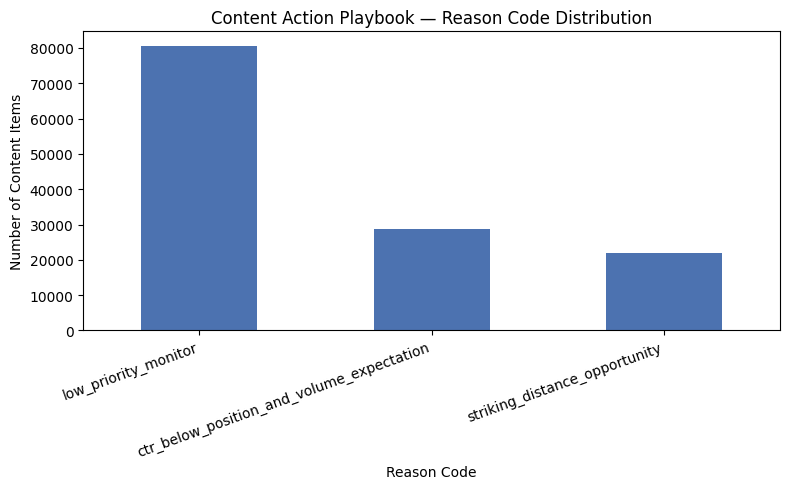

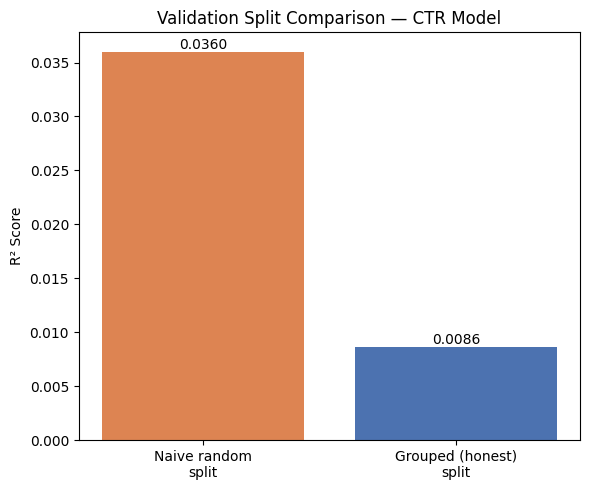

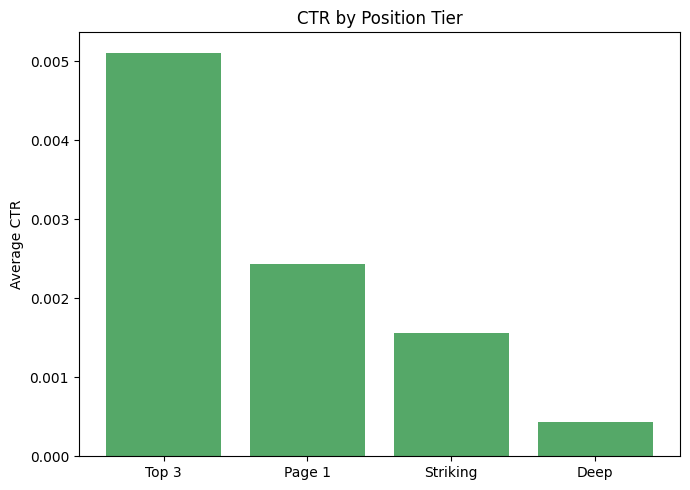

Saved 3 figures to work/figures/


In [10]:
import matplotlib.pyplot as plt
import os
os.makedirs("work/figures", exist_ok=True)

# Figure 1: reason code distribution
fig, ax = plt.subplots(figsize=(8, 5))
queue["reason_code"].value_counts().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Content Action Playbook — Reason Code Distribution")
ax.set_xlabel("Reason Code"); ax.set_ylabel("Number of Content Items")
plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()

# Figure 2: naive vs grouped split R2 (the leakage finding)
fig, ax = plt.subplots(figsize=(6, 5))
splits = ["Naive random\nsplit", "Grouped (honest)\nsplit"]
r2_vals = [0.0360, 0.0086]  # from Week-6 and this notebook's Section 4
bars = ax.bar(splits, r2_vals, color=["#DD8452", "#4C72B0"])
ax.set_ylabel("R² Score"); ax.set_title("Validation Split Comparison — CTR Model")
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x()+bar.get_width()/2, val, f"{val:.4f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("work/figures/split_comparison_r2.png", dpi=150)
plt.show()

# Figure 3: CTR by position tier
ctr_by_pos = con.sql(f"""
    SELECT CASE WHEN avg_position_90d<=3 THEN 'Top 3' WHEN avg_position_90d<=10 THEN 'Page 1'
                WHEN avg_position_90d<=20 THEN 'Striking' ELSE 'Deep' END AS tier,
           AVG(clicks_90d*1.0/NULLIF(impressions_90d,0)) AS avg_ctr
    FROM read_parquet('{base}/fact_content_query_90d.parquet')
    WHERE impressions_90d > 0 AND avg_position_90d >= 1
    GROUP BY 1 ORDER BY avg_ctr DESC
""").df()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(ctr_by_pos["tier"], ctr_by_pos["avg_ctr"], color="#55A868")
ax.set_title("CTR by Position Tier"); ax.set_ylabel("Average CTR")
plt.tight_layout()
plt.savefig("work/figures/ctr_by_position.png", dpi=150)
plt.show()

print("Saved 3 figures to work/figures/")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.